# K-Means Clustering

**K-Means** is one of the simplest and most widely used *clustering* algorithms. Whenever data forms natural groups — *clusters* — in a $D$-dimensional input space, K-Means can identify those clusters and find a representative **centroid** (mean point) for each one.

Unlike the regression and classification tasks from previous exercises, clustering is **unsupervised**: there are no labels $\mathbf{t}$. We only have the inputs $\mathbf{x}_n$, and the goal is to discover structure in them on our own.

The number of clusters $K$ must be chosen in advance. Given $K$, the algorithm partitions the data so as to minimize the total **sum of squared distances** from each point to the centroid of its assigned cluster:
$$J = \sum_{k=1}^K \sum_{n \in \mathcal{C}_k} \|\mathbf{x}_n - \boldsymbol{\mu}_k\|^2$$
where $\mathcal{C}_k$ is the set of points assigned to cluster $k$ and $\boldsymbol{\mu}_k$ is its centroid.

**This notebook covers:**
1. Implementing the K-Means algorithm from scratch (the E-step / M-step iteration)
2. Choosing the number of clusters $K$ with the elbow method
3. A real application: compressing the colors of an image

## Imports and helper functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn import datasets

## A toy dataset

To develop and test our algorithm we first need data that actually contains clusters. `sklearn`'s `make_blobs` generates exactly that: it samples points from several Gaussian "blobs", each with its own center.

- `n_samples`: total number of points
- `centers`: how many blobs to generate
- `cluster_std`: how spread out each blob is (larger = more overlap, harder to separate)

We keep only the input coordinates `X` (shape `(n_samples, 2)`) and **throw away the true labels** — remember, clustering is unsupervised, so our algorithm is not allowed to see them.

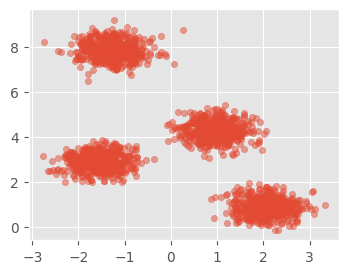

In [ ]:
def get_data(n_samples=2000, n_clusters=4, cluster_std=.4, rs=0):
    return datasets.make_blobs(n_samples=n_samples, centers=n_clusters, cluster_std=cluster_std, random_state=rs)[0]

X = get_data()
plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=20)
plt.show()

## Implementing K-Means

> **Implement the K-Means algorithm** by completing the template below.

K-Means alternates between two steps until the assignments stop changing. (This is an instance of the **Expectation-Maximization** scheme that you will meet again for Gaussian mixtures.)

**E-step** (Bishop Eq. 9.2) — *assign* each point to the nearest centroid:
$$r_{nk} = \begin{cases} 1 & \text{if } k = \arg\min_j \|\mathbf{x}_n - \boldsymbol{\mu}_j\|^2 \\ 0 & \text{otherwise} \end{cases}$$

**M-step** (Bishop Eq. 9.4) — *update* each centroid to the mean of the points currently assigned to it:
$$\boldsymbol{\mu}_k = \frac{\sum_n r_{nk}\,\mathbf{x}_n}{\sum_n r_{nk}}$$

Repeat until **no point changes its assignment** (the algorithm has converged), or until `max_iteration` is reached as a safety limit.

---

**Python note — the leading-underscore convention:**
Methods like `_get_initial_center` and `_dist` start with an underscore. This signals they are *internal helpers*, not part of the public interface (`fit`, `predict`, `plot`). Python does not enforce this — it is purely a readability convention so others know which methods they are meant to call.

**Python note — NumPy broadcasting in `_dist`:**
`X` has shape `(n_samples, n_dim)` while a single `center` has shape `(n_dim,)`. Writing `X - center` makes NumPy automatically subtract the center from *every* row of `X` — no explicit loop over samples needed. Then `np.sum((X - center)**2, axis=-1)` sums along the last axis (the features) to give one squared distance per sample.

**Python note — `np.argmin(D, axis=1)`:**
`D` has shape `(n_samples, n_clusters)`. `np.argmin(..., axis=1)` returns, for each row (sample), the *index* of the smallest entry — i.e. the index of the closest centroid. That index is exactly the cluster assignment.

In [ ]:
class KMeans:

    def __init__(self, n_clusters=3, max_iteration=20):
        """Init k-means algorithm.

        Args:
            n_clusters (int): Assumed number of clusters.
            max_iteration (int): Maximum number of iterations.
        """
        self.n_clusters = n_clusters
        self.max_iteration = max_iteration

    def _get_initial_center(self, X):
        """Pick the initial centers by randomly choosing `n_clusters` data points.

        Args:
            X (ndarray): Input samples.

        Returns:
            ndarray: A (n_clusters, n_dim) shaped array of initial centers.
        """
        np.random.seed(1)
        idx = np.random.choice(len(X), size=self.n_clusters, replace=False)
        return X[idx]

    def _dist(self, X):
        """Compute the squared euclidean distance between every sample and every center.

        Args:
            X (ndarray): Input samples.

        Returns:
            ndarray: A (n_samples, n_clusters) shaped array where entry (n, k) is the
                squared distance of sample n to center k.
        """
        D = np.array([np.sum((X - center)**2, axis=-1) for center in self.centers]).T
        return D

    def fit(self, X):
        """Run k-means until the assignments no longer change.

        Args:
            X (ndarray): Input samples.
        """
        self.X_ = np.array(X)
        # Initialize the centers.
        self.centers = self._get_initial_center(self.X_)
        assignment_old = None

        for _ in range(self.max_iteration):

            # E-step (Bishop Eq. 9.2): assign each sample to the index of its closest center.
            D = self._dist(self.X_)
            assignment = np.argmin(D, axis=1)

            # Stop early if no assignment changed since the last iteration.
            if assignment_old is not None and np.all(assignment == assignment_old):
                break
            assignment_old = assignment

            # M-step (Bishop Eq. 9.4): move each center to the mean of its assigned samples.
            for i in range(self.n_clusters):
                X_cluster = self.X_[assignment == i]
                self.centers[i] = np.mean(X_cluster, axis=0)
        return self

    def predict(self, X):
        """Assign each sample in X to its closest cluster center.

        Args:
            X (ndarray): Input data.

        Returns:
            ndarray: An (n_samples,) shaped array containing cluster indices.
        """
        D = self._dist(X)
        return np.argmin(D, axis=1)

    def plot(self, X):
        """Plot the clustered data together with the cluster centers.

        Args:
            X (ndarray): Input samples.
        """
        if self.centers is not None:
            cluster = self.predict(X)
            plt.figure(figsize=(4, 3))
            plt.scatter(X[:, 0], X[:, 1], c=cluster)
            plt.scatter(self.centers[:, 0], self.centers[:, 1], s=200, marker='X', lw=2,
                        c=np.unique(cluster), edgecolor="white")
        else:
            plt.scatter(X[:, 0], X[:, 1])
        plt.show()

> Now create a `KMeans` instance, fit it on the toy data `X`, and plot the result.

Each point is colored by the cluster it was assigned to, and the large **X** markers show the final centroids. Our data has 4 blobs but the default is `n_clusters=3`, so K-Means is *forced* to merge two of the true blobs into one cluster. Try changing `n_clusters` to 4 and re-running — the centroids should snap neatly onto the four blob centers.

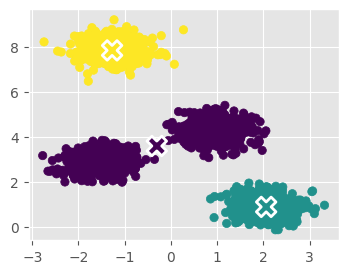

In [ ]:
clusterer = KMeans(max_iteration=10)
clusterer.fit(X)
clusterer.plot(X)

## Choosing the number of clusters $K$

In the example above we *chose* $K$ ourselves. In general we don't know the right number of clusters in advance. A principled heuristic is the **elbow method**: plot the mean squared distance from each point to its assigned centroid as a function of $K$, and look for an "elbow" — the value of $K$ after which adding more clusters brings only diminishing returns.

**Why not simply minimize this error directly?** It *always* decreases as $K$ grows (more centroids can only fit the data better), reaching zero when $K = N$ (every point is its own cluster — useless). So minimizing it would always pick the largest $K$. The elbow is where the curve stops dropping steeply and flattens out, balancing fit quality against model complexity.

> Implement `mse_cluster(X, k)`: fit K-Means with `k` clusters and return the **mean** squared distance from each point to its assigned centroid.

In [ ]:
def mse_cluster(X, k):
    """Fit k-means with k clusters and return the mean squared distance of each
    sample to its assigned center.

    Args:
        X (ndarray): Input data.
        k (int): Number of centers.
    """
    clusterer = KMeans(n_clusters=k)
    clusterer.fit(X)
    assignment = clusterer.predict(X)

    dist_to_centers = []
    for i_center, center in enumerate(clusterer.centers):
        # Squared distance of every sample assigned to this center.
        X_cluster = X[assignment == i_center]
        ms_distance = np.sum((X_cluster - center)**2, axis=-1)
        dist_to_centers.extend(ms_distance )

    return np.mean(dist_to_centers)

> Use `mse_cluster` to compute the error for $K = 1, 2, \ldots, 15$ and plot it against $K$. Where is the elbow?

Our toy data has 4 blobs, so we expect the curve to drop sharply up to $K = 4$ and then flatten — the elbow should sit around $K = 4$.

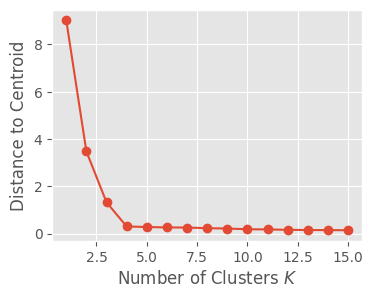

In [ ]:
ki = np.arange(15) + 1
errors = [mse_cluster(X, k) for k in ki]

plt.figure(figsize=(4, 3))
plt.plot(ki, errors, '-o')
plt.xlabel('Number of Clusters $K$')
plt.ylabel('Distance to Centroid')
plt.show()

## K-Means for Color Compression

A neat real-world application of clustering is **image color compression**. A standard image stores each pixel as an (R, G, B) triple — one byte per channel — allowing up to $256^3 \approx 16$ million distinct colors. Most images actually use only a small fraction of those.

**The idea:** treat each pixel's RGB values as a single point in 3D color space. Cluster all the pixels into $K$ groups, then replace every pixel's color with its cluster's centroid color. The result only needs $K$ distinct colors (the centroids) plus one cluster index per pixel — a big reduction from a full 24-bit color per pixel.

The image below is stored as a 3D array of shape `(height, width, channels)` with integer values in $[0, 255]$.

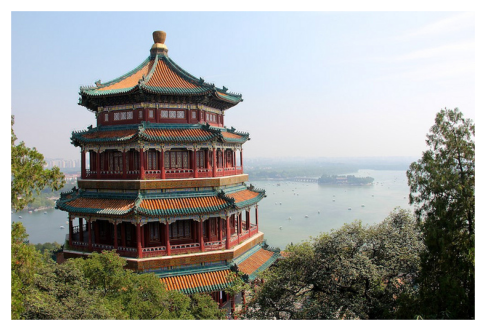

(427, 640, 3)


In [ ]:
china = datasets.load_sample_image("china.jpg")
plt.figure(figsize=(6, 6))
plt.axes(xticks=[], yticks=[])
plt.imshow(china)
plt.show()
print(china.shape)

> Reshape the image into `(n_samples, n_features)` format and rescale the pixel values to $[0, 1]$.

**Why reshape?** K-Means treats each pixel as one data point with 3 features (R, G, B). The image is initially 3D (`height × width × 3`); we need to flatten the two spatial dimensions into one, giving a 2D array of shape `(height · width, 3)`.

**Python note — `reshape`:** `array.reshape(n_rows, n_cols)` reinterprets the same data with new dimensions (the total number of elements must stay the same). Here `china.reshape(-1, 3)` collapses height and width into a single axis of pixels; the `-1` tells NumPy to infer that length automatically.

**Why rescale to $[0, 1]$?** K-Means uses Euclidean distance, which is sensitive to scale. Dividing by 255 maps the byte range $[0, 255]$ to $[0, 1]$ so the three channels are treated on equal footing.

In [ ]:
data = china / 255.0
data = data.reshape(-1, 3)
print(data.shape)

(273280, 3)


> Use the following helper function to visualize a random subset of the pixels in color space.

In [ ]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # Choose a random subset so the scatter plot stays readable.
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    # A single 3D scatter: each pixel is a point in (Red, Green, Blue) space.
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(R, G, B, color=colors, marker='o')
    ax.set(xlabel='Red', ylabel='Green', zlabel='Blue', xlim=(0, 1), ylim=(0, 1), zlim=(0, 1))
    fig.suptitle(title, size=15)


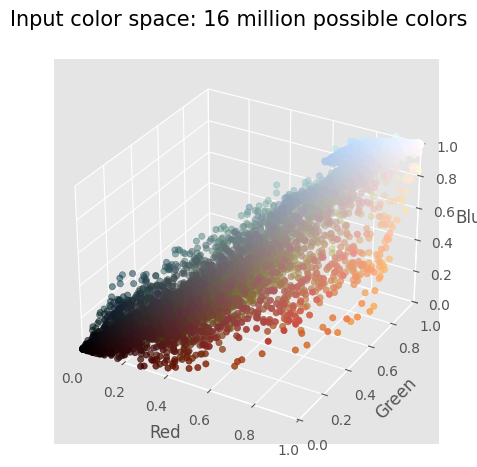

In [ ]:
plot_pixels(data, title='Input color space: 16 million possible colors')

> Reduce the ~16 million possible colors to just 16 by clustering the pixels in color space. Use `MiniBatchKMeans` from `sklearn.cluster`.

**Python note — why `MiniBatchKMeans`?** Our own `KMeans` recomputes distances to all centers for *every* pixel on *every* iteration. With ~270,000 pixels that is slow. `MiniBatchKMeans` is sklearn's optimized variant: each iteration it updates the centroids using a small random *mini-batch* of points instead of the whole dataset. The result is almost identical but runs much faster — exactly what we need at this scale.

After fitting, `kmeans.cluster_centers_` holds the 16 representative colors and `kmeans.predict(data)` gives each pixel's cluster index. Indexing the centers with those predictions, `cluster_centers_[predict(data)]`, replaces each pixel with its cluster's color.

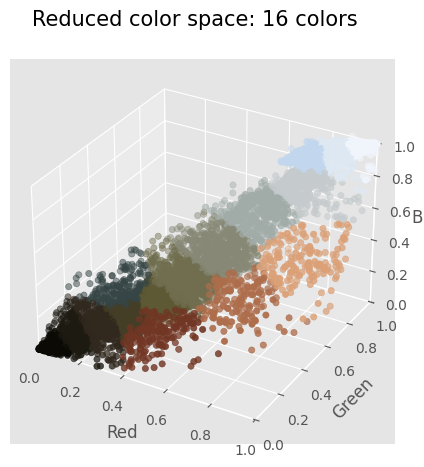

In [ ]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors, title='Reduced color space: 16 colors')

> Reshape the compressed colors back to the original image shape and display the original and 16-color images side by side.

**What to look for:**
- Smooth color gradients in the original become visible **banding** in the compressed image — the cost of quantizing to only 16 colors.
- Despite that, the overall structure and content of the image is preserved remarkably well.
- Try re-running with 32 or 64 colors (change the number passed to `MiniBatchKMeans`). At what point does the compressed image look acceptable to you?

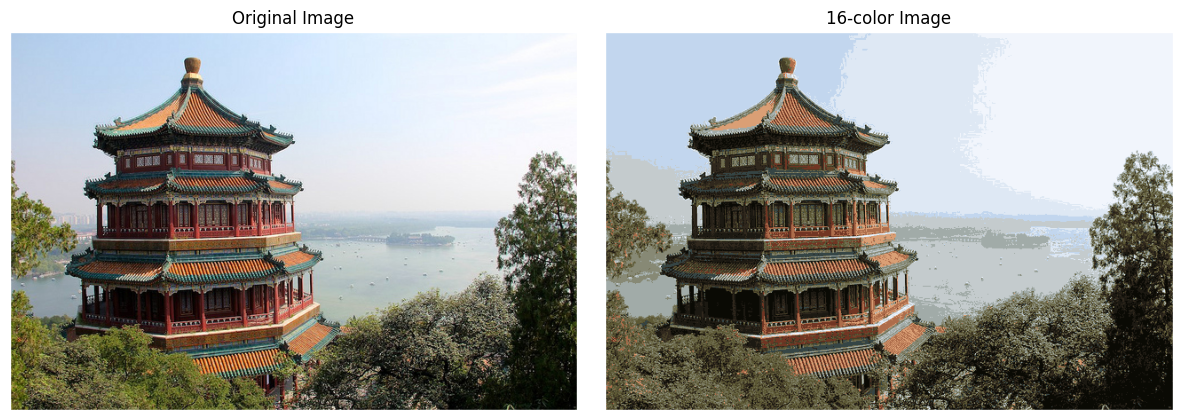

In [ ]:
china_recolored = new_colors.reshape(china.shape)

fig, ax = plt.subplots(1, 2, figsize=(15, 10), subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(china)
ax[0].set_title('Original Image', size=12)
ax[1].imshow(china_recolored)
ax[1].set_title('16-color Image', size=12)
plt.show()